# A3 06 — Fidelity at estimated bone-MNI years

## Purpose
This notebook uses estimated bone death year as the best available temporal assignment for MNI. It compares living composition with bone-MNI composition in the exact estimated year and repeats the calculation with a ±1-year bone window. The pooled historical and fence-period analyses remain primary because estimated years are approximate and neighbouring windows overlap.

**Plain-language example.** A bone assigned to 2003 is our best estimate, not a dated event. We first compare it with the 2003 census, then check whether including bones assigned to 2002–2004 changes the answer.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'scripts'))
from a3_common import *
processed_dir, output_dir = ensure_a3_directories(ROOT)
aerial = pd.read_pickle(processed_dir / 'aerial_primary.pkl')
ground = pd.read_pickle(processed_dir / 'ground_historical_sweetwaters.pkl')
bones = pd.read_pickle(processed_dir / 'bones_primary_excluding_2024.pkl')
decisions = pd.read_csv(processed_dir / 'taxon_decisions.csv')
aerial_taxa = decisions.loc[decisions['matched_analysis'], 'taxon'].tolist()
ground_taxa = eligible_shared_taxa(ground, bones[bones['Sector'].eq('Eastern')])
print(f'Aerial–MNI taxa: {len(aerial_taxa)}; ground–MNI taxa: {len(ground_taxa)}')


Aerial–MNI taxa: 15; ground–MNI taxa: 14


## Exact-year and neighbouring-year comparisons

For each living census year, the exact analysis uses bone MNI carrying the same estimated death year. The sensitivity analysis sums bone MNI assigned within one year on either side. Bray–Curtis, Pearson, Spearman, taxon richness, and sample totals are reported. MNI ≥10 is an adequacy flag, not a guarantee of precision. Correlations are across matched taxa within a year; years are not treated as replicate taxa.


In [2]:
def temporal_matches(living, bone, taxa, method, window):
    rows, taxon_rows = [], []
    for sector in sorted(living['Sector'].unique()):
        live_sector = living[living['Sector'].eq(sector)]
        bone_sector = bone[bone['Sector'].eq(sector)]
        for year in sorted(live_sector['Year'].unique()):
            live_sample = live_sector[live_sector['Year'].eq(year)]
            bone_sample = bone_sector[bone_sector['Year'].between(year-window, year+window)]
            live_vec = live_sample[live_sample['Species'].isin(taxa)].groupby('Species')['Total'].sum().reindex(taxa, fill_value=0.0)
            bone_vec = bone_sample[bone_sample['Species'].isin(taxa)].groupby('Species')['Total'].sum().reindex(taxa, fill_value=0.0)
            if bone_vec.sum() <= 0 or live_vec.sum() <= 0:
                continue
            lp, bp = live_vec/live_vec.sum(), bone_vec/bone_vec.sum()
            metrics = composition_comparison(live_vec, bone_vec)
            p_value = float(pearsonr(lp, bp).pvalue)
            used = ', '.join(map(str, sorted(bone_sample.loc[bone_sample['Species'].isin(taxa), 'Year'].unique())))
            rows.append({'living_method':method, 'sector':sector, 'living_year':int(year), 'bone_window':window, 'bone_years_used':used, 'living_count':float(live_vec.sum()), 'living_taxa':int((live_vec>0).sum()), 'bone_MNI':float(bone_vec.sum()), 'bone_taxa':int((bone_vec>0).sum()), 'bone_MNI_ge_10':bool(bone_vec.sum()>=10), 'pearson_p':p_value, **metrics})
            for taxon in taxa:
                taxon_rows.append({'living_method':method, 'sector':sector, 'living_year':int(year), 'bone_window':window, 'taxon':taxon, 'living_relative':float(lp[taxon]), 'bone_relative':float(bp[taxon]), 'difference':float(bp[taxon]-lp[taxon])})
    return pd.DataFrame(rows), pd.DataFrame(taxon_rows)


In [3]:
result_frames, taxon_frames = [], []
for window in (0, 1):
    aerial_results, aerial_details = temporal_matches(aerial, bones, aerial_taxa, 'aerial', window)
    ground_results, ground_details = temporal_matches(ground, bones[bones['Sector'].eq('Eastern')], ground_taxa, 'ground', window)
    result_frames.extend([aerial_results, ground_results])
    taxon_frames.extend([aerial_details, ground_details])
temporal_results = pd.concat(result_frames, ignore_index=True).sort_values(['living_method','sector','living_year','bone_window'])
temporal_taxa = pd.concat(taxon_frames, ignore_index=True)
temporal_results.to_csv(output_dir / 'A3_06_estimated_year_fidelity.csv', index=False)
temporal_taxa.to_csv(output_dir / 'A3_06_estimated_year_taxon_compositions.csv', index=False)
exact_results = temporal_results[temporal_results['bone_window'].eq(0)].copy()
window_results = temporal_results[temporal_results['bone_window'].eq(1)].copy()
display(exact_results.round(3))
display(window_results.round(3))


,living_method,sector,living_year,bone_window,bone_years_used,living_count,living_taxa,bone_MNI,bone_taxa,bone_MNI_ge_10,pearson_p,bray_curtis,pearson,spearman,taxa_compared
0,aerial,Eastern,2002,0,2002,935.0,11,23.0,5,True,0.000,0.373,0.864,0.392,15
1,aerial,Eastern,2003,0,2003,979.0,10,10.0,5,True,0.000,0.451,0.793,0.322,15
2,aerial,Eastern,2006,0,2006,1671.0,14,13.0,6,True,0.144,0.563,0.396,0.477,15
3,aerial,Eastern,2008,0,2008,3965.0,14,11.0,3,True,0.407,0.676,0.231,0.473,15
4,aerial,Eastern,2010,0,2010,2417.0,13,5.0,3,False,0.773,0.787,0.081,0.246,15
5,aerial,Eastern,2013,0,2013,2669.0,14,22.0,7,True,0.029,0.417,0.562,0.845,15
6,aerial,Eastern,2014,0,2014,3506.0,14,23.0,6,True,0.000,0.299,0.834,0.856,15
7,aerial,Western,2006,0,2006,4556.0,11,4.0,3,False,0.000,0.337,0.872,0.668,15
8,aerial,Western,2008,0,2008,5944.0,11,4.0,3,False,0.017,0.557,0.605,0.307,15
9,aerial,Western,2010,0,2010,6625.0,12,1.0,1,False,0.932,0.922,0.024,0.310,15


,living_method,sector,living_year,bone_window,bone_years_used,living_count,living_taxa,bone_MNI,bone_taxa,bone_MNI_ge_10,pearson_p,bray_curtis,pearson,spearman,taxa_compared
15,aerial,Eastern,2002,1,"2002, 2003",935.0,11,33.0,8,True,0.000,0.329,0.909,0.479,15
16,aerial,Eastern,2003,1,"2002, 2003",979.0,10,33.0,8,True,0.000,0.452,0.802,0.614,15
17,aerial,Eastern,2005,1,2006,1359.0,13,13.0,6,True,0.000,0.353,0.862,0.628,15
18,aerial,Eastern,2006,1,2006,1671.0,14,13.0,6,True,0.144,0.563,0.396,0.477,15
19,aerial,Eastern,2007,1,"2006, 2008",2133.0,13,24.0,6,True,0.024,0.481,0.578,0.652,15
20,aerial,Eastern,2008,1,2008,3965.0,14,11.0,3,True,0.407,0.676,0.231,0.473,15
21,aerial,Eastern,2009,1,"2008, 2010",3158.0,15,16.0,4,True,0.444,0.620,0.214,0.458,15
22,aerial,Eastern,2010,1,2010,2417.0,13,5.0,3,False,0.773,0.787,0.081,0.246,15
23,aerial,Eastern,2012,1,2013,2497.0,12,22.0,7,True,0.181,0.454,0.365,0.874,15
24,aerial,Eastern,2013,1,"2013, 2014",2669.0,14,45.0,7,True,0.008,0.346,0.656,0.853,15


## Coverage and sensitivity summary

The summary counts comparisons rather than claiming independent temporal replicates. Median statistics are descriptive. The paired exact-versus-window table shows how much the temporal assignment changes when neighbouring estimated years are included.


In [4]:
coverage_summary = (temporal_results.groupby(['living_method','sector','bone_window'])
    .agg(comparisons=('living_year','size'), adequate_MNI=('bone_MNI_ge_10','sum'), median_bone_MNI=('bone_MNI','median'), median_bray_curtis=('bray_curtis','median'), median_pearson=('pearson','median'), median_spearman=('spearman','median')).reset_index())
coverage_summary.to_csv(output_dir / 'A3_06_temporal_fidelity_summary.csv', index=False)
paired = exact_results.merge(window_results, on=['living_method','sector','living_year'], suffixes=('_exact','_window'))
paired['BC_window_minus_exact'] = paired['bray_curtis_window'] - paired['bray_curtis_exact']
paired['pearson_window_minus_exact'] = paired['pearson_window'] - paired['pearson_exact']
paired.to_csv(output_dir / 'A3_06_exact_vs_window_sensitivity.csv', index=False)
display(coverage_summary.round(3))
paired[['living_method','sector','living_year','bone_MNI_exact','bone_MNI_window','bray_curtis_exact','bray_curtis_window','BC_window_minus_exact','pearson_exact','pearson_window']].round(3)


,living_method,sector,bone_window,comparisons,adequate_MNI,median_bone_MNI,median_bray_curtis,median_pearson,median_spearman
0,aerial,Eastern,0,7,6,13.0,0.451,0.562,0.473
1,aerial,Eastern,1,12,11,22.5,0.453,0.616,0.621
2,aerial,Western,0,5,2,4.0,0.411,0.821,0.527
3,aerial,Western,1,10,4,6.5,0.373,0.828,0.577
4,ground,Eastern,0,3,3,23.0,0.362,0.854,0.617
5,ground,Eastern,1,6,6,25.0,0.323,0.853,0.674


,living_method,sector,living_year,bone_MNI_exact,bone_MNI_window,bray_curtis_exact,bray_curtis_window,BC_window_minus_exact,pearson_exact,pearson_window
0,aerial,Eastern,2002,23.0,33.0,0.373,0.329,-0.044,0.864,0.909
1,aerial,Eastern,2003,10.0,33.0,0.451,0.452,0.001,0.793,0.802
2,aerial,Eastern,2006,13.0,13.0,0.563,0.563,0.000,0.396,0.396
3,aerial,Eastern,2008,11.0,11.0,0.676,0.676,0.000,0.231,0.231
4,aerial,Eastern,2010,5.0,5.0,0.787,0.787,0.000,0.081,0.081
5,aerial,Eastern,2013,22.0,45.0,0.417,0.346,-0.072,0.562,0.656
6,aerial,Eastern,2014,23.0,45.0,0.299,0.313,0.014,0.834,0.805
7,aerial,Western,2006,4.0,4.0,0.337,0.337,0.000,0.872,0.872
8,aerial,Western,2008,4.0,4.0,0.557,0.557,0.000,0.605,0.605
9,aerial,Western,2010,1.0,1.0,0.922,0.922,0.000,0.024,0.024


## Fidelity through estimated time

Each panel shows exact estimated-year Bray–Curtis and the ±1-year sensitivity result. The y-axis is reversed so that smaller dissimilarity (greater similarity) appears higher. Filled exact-year circles meet MNI ≥10; hollow circles do not. Lines connect values only to guide the eye and are not fitted temporal trends.


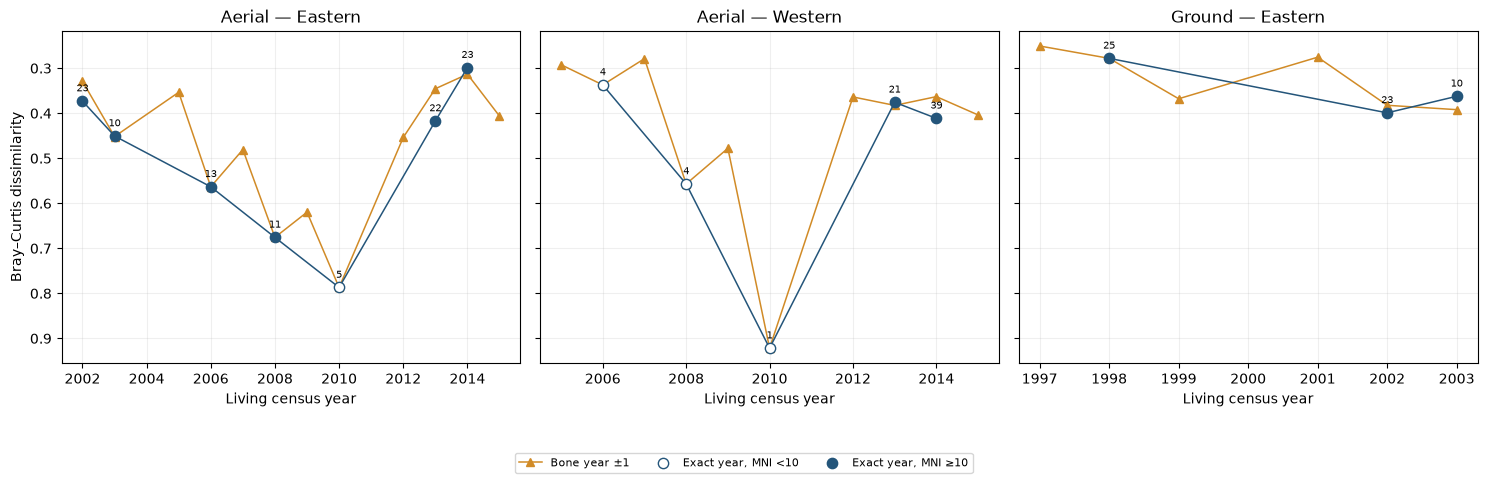

In [5]:
panels = [('aerial','Eastern'),('aerial','Western'),('ground','Eastern')]
fig, axes = plt.subplots(1,3,figsize=(15,4.8),sharey=True)
for ax, (method, sector) in zip(axes, panels):
    e = exact_results[(exact_results['living_method'].eq(method)) & exact_results['sector'].eq(sector)].sort_values('living_year')
    w = window_results[(window_results['living_method'].eq(method)) & window_results['sector'].eq(sector)].sort_values('living_year')
    ax.plot(w['living_year'], w['bray_curtis'], color='#d18b27', marker='^', linewidth=1.1, label='Bone year ±1')
    ax.plot(e['living_year'], e['bray_curtis'], color='#24557a', linewidth=1.1)
    for adequate, group in e.groupby('bone_MNI_ge_10'):
        ax.scatter(group['living_year'], group['bray_curtis'], s=55, facecolor='#24557a' if adequate else 'white', edgecolor='#24557a', label='Exact year, MNI ≥10' if adequate else 'Exact year, MNI <10', zorder=3)
    for _, row in e.iterrows():
        ax.annotate(str(int(row['bone_MNI'])), (row['living_year'],row['bray_curtis']), xytext=(0,7), textcoords='offset points', ha='center', fontsize=7)
    ax.set_title(f'{method.capitalize()} — {sector}')
    ax.set_xlabel('Living census year')
    ax.grid(alpha=0.2)
    ax.invert_yaxis()  # smaller dissimilarity (greater similarity) is plotted higher
axes[0].set_ylabel('Bray–Curtis dissimilarity')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=8)
fig.tight_layout(rect=(0,0.11,1,1))
fig.savefig(output_dir / 'A3_06_estimated_year_fidelity.png', dpi=300, bbox_inches='tight')
fig.savefig(output_dir / 'A3_06_estimated_year_fidelity.pdf', bbox_inches='tight')
plt.show()


## Interpretation

Estimated death year is the only available temporal assignment for bone MNI, so these comparisons use it directly rather than discarding the annual information. Exact-year aerial–bone overlap occurred in seven Eastern and five Western years. Six Eastern matches reached summed matched-taxon bone MNI ≥10, compared with two Western matches. Across those adequate exact-year comparisons, Eastern Bray–Curtis dissimilarity ranged from 0.299 to 0.676 and Pearson r from 0.231 to 0.864; the two adequate Western years (2013 and 2014) had Bray–Curtis values of 0.376 and 0.411 and Pearson r values of 0.821 and 0.834.

The ground census supplied three adequate exact-year Eastern comparisons: 1998, 2002, and 2003. Their Bray–Curtis values were 0.278, 0.399, and 0.362, while Pearson r was 0.901, 0.784, and 0.854. Thus, the estimated-year results generally show a recognizable living-community signal, but correspondence varies substantially among years.

Pooling bone MNI from the living year ±1 increased the number of adequate comparisons from 6 to 11 in the Eastern aerial series and from 2 to 4 in the Western series; all six available ground-window comparisons reached MNI ≥10. This improves descriptive coverage but does not create independent observations: neighbouring living years can reuse the same bone MNI, and the weathering-derived year remains an estimate. Exact-year results are therefore the principal annual description, the ±1-year calculation is a sensitivity analysis, and pooled historical and pre/post-period comparisons remain the most stable summaries.

The temporal fidelity calculations include only the 15 prespecified matched taxa. The primary bone dataset also contained 415 excluded MNI: unidentified mammal 249, medium bovid 79, large bovid 26, small bovid 20, cattle 12, small bird 7, ostrich 5, unresolved ungulate 5, medium bird 4, hare 2, spotted hyena 2, and one each of vervet monkey, tree hyrax, unresolved rhinoceros, and lion. These remain available for bone-only description but cannot be assigned to the matched species set without unsupported assumptions.

**Figure. Estimated-year temporal fidelity.** Points show Bray–Curtis dissimilarity between living relative abundance and bone-MNI relative abundance for the exact estimated year and for a ±1-year bone window. The y-axis is reversed so that lower dissimilarity (greater similarity) plots higher. Numbers beside points are summed matched-taxon bone MNI; filled points meet the descriptive MNI ≥10 rule. The ±1-year series is a sensitivity analysis because adjacent windows overlap.
